In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load datasest
df=pd.read_csv('SuperStore_Sales_Dataset CSV.csv')
df.head()

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2
0,4918,CA-2019-160304,01-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online,NaN,NaN
1,4919,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online,NaN,NaN
2,4920,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Technology,Phones,GE 30522EE2,231.98,2,67.2742,NaN,Cards,NaN,NaN
3,3074,CA-2019-125206,03-01-2019,05-01-2019,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,NaN,Online,NaN,NaN
4,8604,US-2019-116365,03-01-2019,08-01-2019,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,NaN,Online,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID+O6G3A1:R6  5901 non-null   int64  
 1   Order ID          5901 non-null   object 
 2   Order Date        5901 non-null   object 
 3   Ship Date         5901 non-null   object 
 4   Ship Mode         5901 non-null   object 
 5   Customer ID       5901 non-null   object 
 6   Customer Name     5901 non-null   object 
 7   Segment           5901 non-null   object 
 8   Country           5901 non-null   object 
 9   City              5901 non-null   object 
 10  State             5901 non-null   object 
 11  Region            5901 non-null   object 
 12  Product ID        5901 non-null   object 
 13  Category          5901 non-null   object 
 14  Sub-Category      5901 non-null   object 
 15  Product Name      5901 non-null   object 
 16  Sales             5901 non-null   float64


In [5]:
#Count duplicate records in the dataset
df.duplicated().sum()

np.int64(0)

In [6]:
#Columns added for calculating shipping time
df['Order Date']=pd.to_datetime(df['Order Date'],dayfirst=True)
df['Ship Date']=pd.to_datetime(df['Ship Date'],dayfirst=True)

In [7]:
df.head()

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online,NaN,NaN
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online,NaN,NaN
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,Technology,Phones,GE 30522EE2,231.98,2,67.2742,NaN,Cards,NaN,NaN
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,NaN,Online,NaN,NaN
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,NaN,Online,NaN,NaN


In [8]:
#Columns added for better analysis
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month
df['Month Name']=df['Order Date'].dt.month_name()
df.head()

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2,Year,Month,Month Name
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,73.94,1,28.2668,NaN,Online,NaN,NaN,2019,1,January
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,173.94,3,38.2668,NaN,Online,NaN,NaN,2019,1,January
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,231.98,2,67.2742,NaN,Cards,NaN,NaN,2019,1,January
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,114.46,2,28.6150,NaN,Online,NaN,NaN,2019,1,January
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,30.08,2,-5.2640,NaN,Online,NaN,NaN,2019,1,January


In [9]:
#Average Shipping Days
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Shipping_Days'].mean()

np.float64(3.9269615319437383)

In [10]:
#Shipping days by City
df.groupby('City')['Shipping_Days'].mean()

City
Aberdeen       3.000000
Abilene        2.000000
Akron          4.076923
Albuquerque    5.100000
Alexandria     4.500000
                 ...   
Woodstock      4.500000
Woonsocket     3.000000
Yonkers        4.250000
York           4.400000
Yuma           2.000000
Name: Shipping_Days, Length: 452, dtype: float64

In [11]:
#Shipping days based on Ship Mode
df.groupby('Ship Mode')['Shipping_Days'].mean().sort_values()

Ship Mode
Same Day          0.052326
First Class       2.140772
Second Class      3.217088
Standard Class    5.045494
Name: Shipping_Days, dtype: float64

In [12]:
#Frequency of Shipping days
df['Shipping_Days'].value_counts().sort_index()

Shipping_Days
0     326
1     265
2     783
3     624
4    1552
5    1217
6     763
7     369
8       2
Name: count, dtype: int64

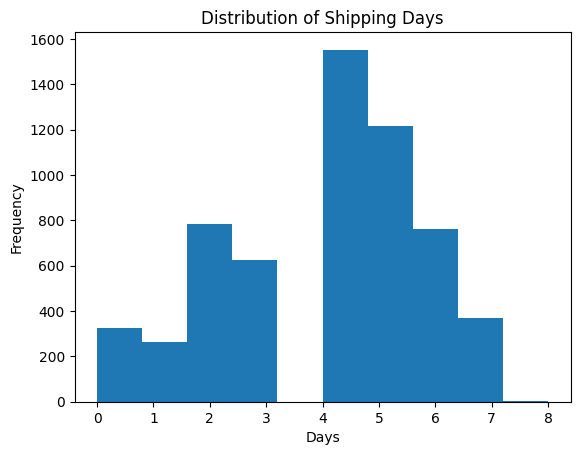

In [13]:
df['Shipping_Days'].plot(kind='hist', bins=10)
plt.title("Distribution of Shipping Days")
plt.xlabel("Days")
plt.show()

In [14]:
#Correlation with Profit
df[['Shipping_Days', 'Profit']].corr()

,Shipping_Days,Profit
Shipping_Days,1.000000,-0.008532
Profit,-0.008532,1.000000


In [46]:
#Sales and Profit based on Segment
summary_table = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum'
})
summary_table

,Sales,Profit
Segment,,
Consumer,753002.1291,81338.5875
Corporate,509743.1262,57805.7991
Home Office,303059.0679,36117.7193


In [45]:
#Sales based on Category
df.groupby('Category')['Sales'].sum()

Category
Furniture          451508.6452
Office Supplies    643707.6870
Technology         470587.9910
Name: Sales, dtype: float64

In [44]:
#Sub-Category Sales and Profit
sub_summary=df.groupby('Sub-Category').agg(
    {
        'Sales':'sum',
        'Profit':'sum'
    }
).sort_values(by='Sales')
sub_summary

,Sales,Profit
Sub-Category,,
Fasteners,15205.2380,598.4175
Envelopes,16542.4640,3508.5073
Labels,19397.4560,2937.2212
Supplies,36720.9860,-1654.2767
Art,50762.9760,3635.9257
Bookcases,57577.6862,-342.8883
Copiers,59735.7980,42774.5828
Appliances,80305.2470,13166.6098
Machines,91987.5610,38.1024


In [43]:
#Sales and Profit by Region
salesprofit_region=df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values(by='Sales')
salesprofit_region

,Sales,Profit
Region,,
South,252121.0810,26551.7163
Central,341007.5242,27450.0071
East,450234.6660,53400.4243
West,522441.0520,67859.9582


In [19]:
#Profit by States
df.groupby('State')['Profit'].sum().sort_values(ascending=False)

State
California              49372.1750
New York                41012.0212
Washington              21466.6555
Michigan                17480.2806
Indiana                 15524.6596
Georgia                  9994.4165
Virginia                 9657.4876
New Jersey               7213.0952
Delaware                 7029.9107
Kentucky                 5968.3840
Rhode Island             5627.4571
Wisconsin                5252.5593
Maryland                 3860.6173
Oklahoma                 3431.8469
Alabama                  3336.3075
Missouri                 3099.2883
Minnesota                2864.3483
Massachusetts            2768.8647
Nevada                   2598.4455
Mississippi              2504.2418
Connecticut              2339.0135
Arkansas                 1873.9949
Nebraska                 1775.4605
Montana                  1465.9255
Louisiana                1301.1721
Utah                     1054.5308
Vermont                  1053.0513
New Mexico                852.3424
New Hampshire 

In [40]:
#Shipping Mode and Shipping Days
df.groupby('Ship Mode')['Shipping_Days'].mean().sort_values()

Ship Mode
Same Day          0.052326
First Class       2.140772
Second Class      3.217088
Standard Class    5.045494
Name: Shipping_Days, dtype: float64

In [39]:
#Shipping Mode and Profit
df.groupby('Ship Mode')['Profit'].sum().sort_values()

Ship Mode
Same Day           8808.8243
First Class       29749.8665
Second Class      36936.0265
Standard Class    99767.3886
Name: Profit, dtype: float64

In [21]:
#Payment Mode and Sales
df.groupby('Payment Mode')['Sales'].sum()

Payment Mode
COD       667417.7513
Cards     344393.1112
Online    553993.4607
Name: Sales, dtype: float64

In [22]:
#Product Return sum
df['Returns'].notnull().sum()

np.int64(287)

In [23]:
#Product Return rate
(df['Returns'].notnull().mean())*100

np.float64(4.863582443653618)

In [37]:
#Year-wise Sales
df.groupby('Year')['Sales'].sum().round(2)

Year
2019     564679.54
2020    1001124.79
Name: Sales, dtype: float64

In [25]:
#Growth percentage wrt previous year
growth = df.groupby("Year")["Sales"].sum().pct_change() * 100

Growth:
Year
2019          NaN
2020    77.290785
Name: Sales, dtype: float64


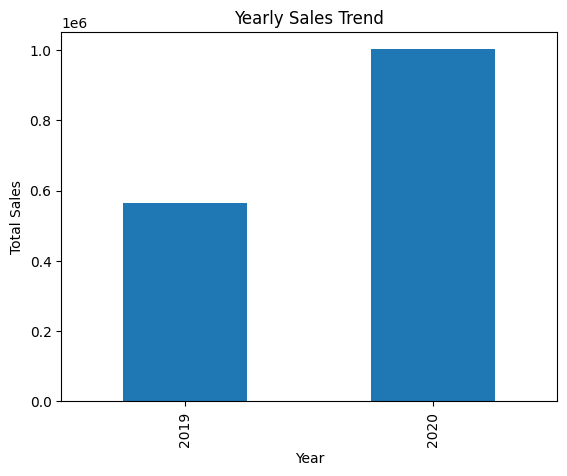

In [26]:
#Annual Sales
df.groupby('Year')['Sales'].sum().plot(kind='bar')
plt.title("Yearly Sales Trend")
plt.ylabel("Total Sales")
plt.show()

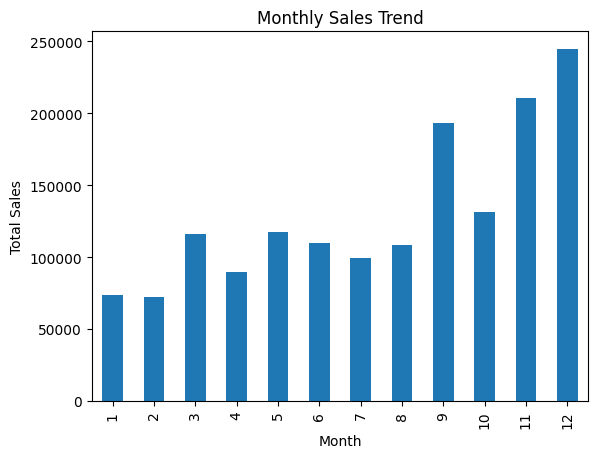

In [27]:
#Month-wise Sales
df.groupby('Month')['Sales'].sum().plot(kind='bar')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

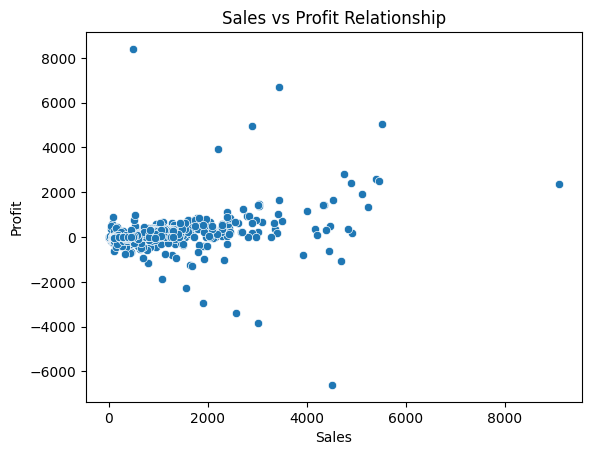

In [28]:
#Sales vs Profit relationship
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit Relationship")
plt.show()

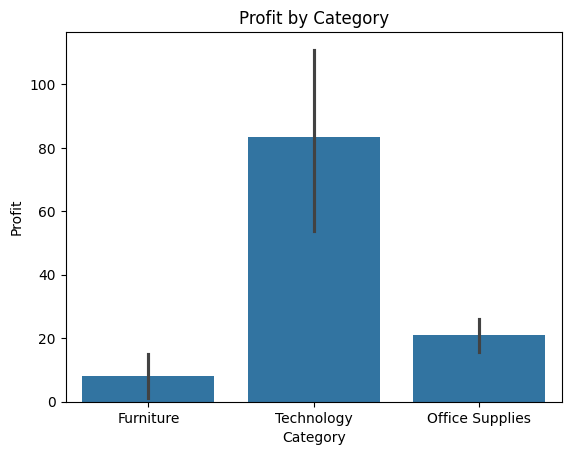

In [29]:
#Category Profit Comparison
sns.barplot(x='Category', y='Profit', data=df)
plt.title("Profit by Category")
plt.show()

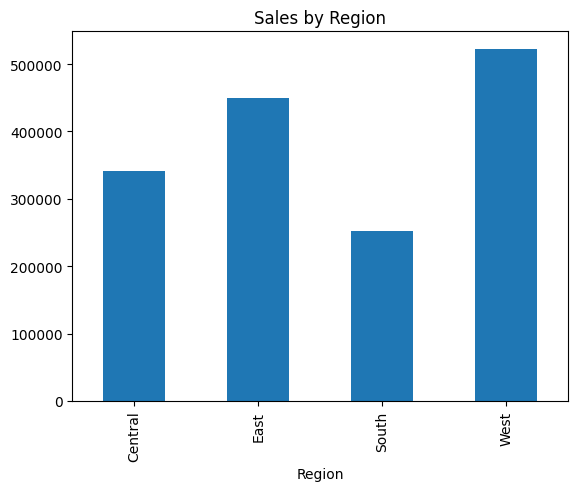

In [30]:
#Region Sales Visualization
df.groupby('Region')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

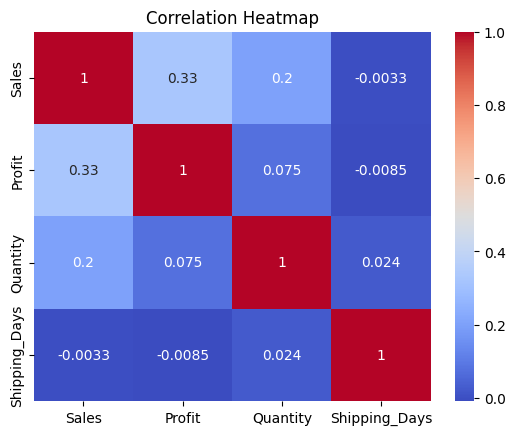

In [31]:
#Heatmap
corr = df[['Sales','Profit','Quantity','Shipping_Days']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [32]:
#Top 10 products by sales
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

Product Name
3D Systems Cube Printer, 2nd Generation, Magenta                               14334.890
Canon imageCLASS 2200 Advanced Copier                                          14076.824
Hewlett Packard LaserJet 3310 Copier                                           13837.732
GBC DocuBind TL300 Electric Binding System                                     12890.258
GBC DocuBind P400 Electric Binding System                                      12577.108
Samsung Galaxy Mega 6.3                                                        12370.708
Martin Yale Chadless Opener Electric Letter Opener                             12268.902
HON 5400 Series Task Chairs for Big and Tall                                   11887.562
Global Troy Executive Leather Low-Back Tilter                                  10217.894
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     9756.524
Name: Sales, dtype: float64

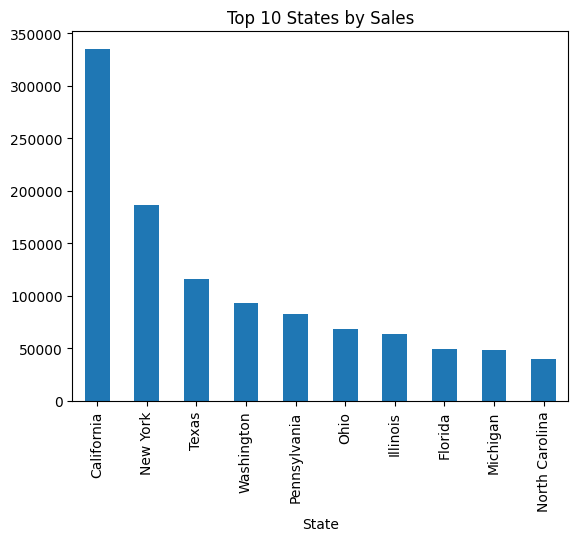

In [33]:
#Top 10 States by Sales
df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 States by Sales")
plt.show()

In [34]:
#Loss-Making Subcategories
df.groupby('Sub-Category')['Profit'].sum().sort_values().head(10)

Sub-Category
Tables        -11091.6365
Supplies       -1654.2767
Bookcases       -342.8883
Machines          38.1024
Fasteners        598.4175
Labels          2937.2212
Envelopes       3508.5073
Art             3635.9257
Furnishings     8034.4328
Appliances     13166.6098
Name: Profit, dtype: float64

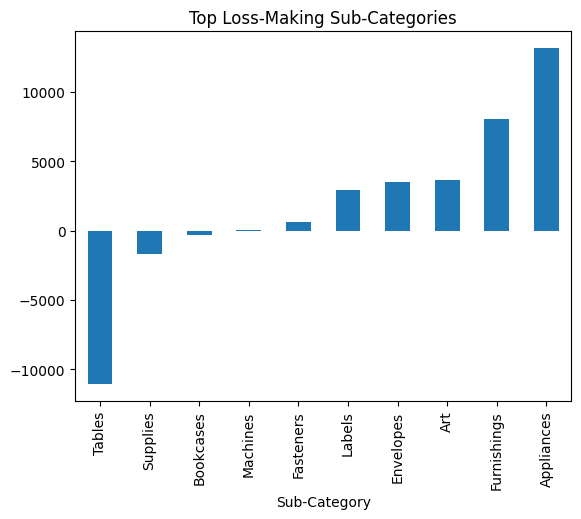

In [47]:
# Loss-making subcategories (visualization)
df.groupby('Sub-Category')['Profit'].sum().sort_values().head(10).plot(kind='bar')
plt.title("Top Loss-Making Sub-Categories")
plt.show()

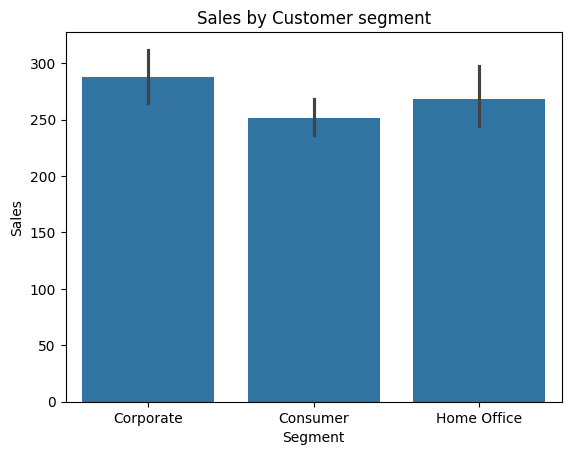

In [51]:
#Sales by Segment Visualization
sns.barplot(x='Segment', y='Sales', data=df)
plt.title("Sales by Customer segment")
plt.show()

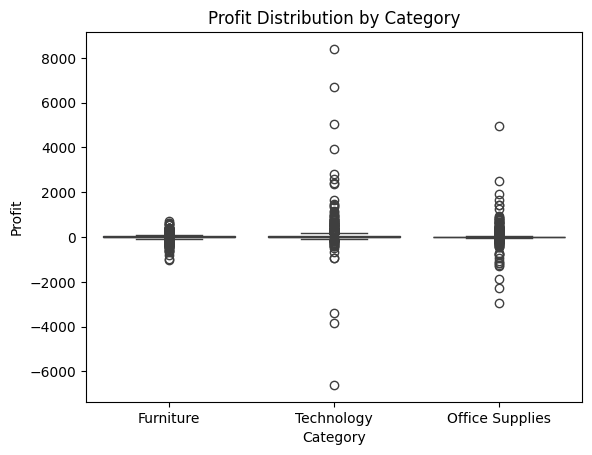

In [36]:
#Profit Variability
sns.boxplot(x='Category', y='Profit', data=df)
plt.title("Profit Distribution by Category")
plt.show()

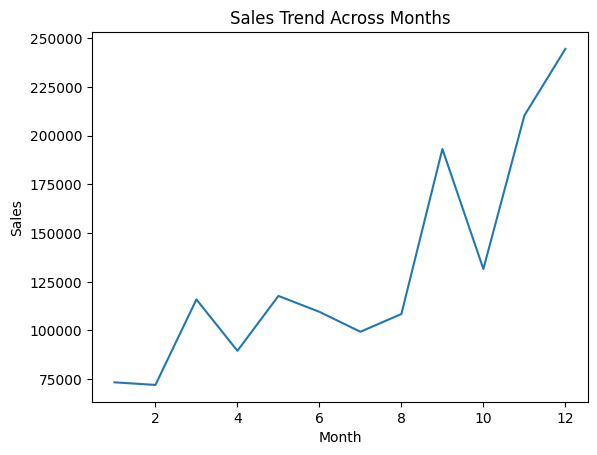

In [48]:
#Sales through Months
sns.lineplot(x='Month', y='Sales', data=df.groupby('Month')['Sales'].sum().reset_index())
plt.title("Sales Trend Across Months")
plt.show()

## Key Business Insights

• Sales increased significantly from 2019 to 2020 (~77% growth), indicating strong business expansion during this period.

• The Consumer segment contributes the highest total sales, making it the most important customer segment for revenue generation.

• The Corporate segment shows the highest average order value, suggesting that corporate customers tend to place higher-value orders.

• The Technology category generates the highest profit, making it the most profitable product category for the company.

• Some sub-categories such as Tables, Bookcases, and Supplies generate negative profit, indicating possible pricing issues, excessive discounts, or high operational costs.

• The West region generates the highest sales and profit, followed by the East region, while the South region records the lowest performance.

• Sales are distributed across all regions rather than concentrated in one location, indicating a diversified geographic customer base.

• The average shipping time is around 4 days, which suggests relatively consistent delivery performance.

• The product return rate is relatively low compared to total orders, indicating satisfactory product quality and customer satisfaction.

## Conclusion

This analysis examined the Superstore sales dataset to understand sales performance, customer segments, product profitability, and regional distribution. The results show strong sales growth from 2019 to 2020 and highlight the Consumer segment as the primary driver of total revenue, while Corporate customers generate higher average order values.

The Technology category produces the highest profit, whereas some sub-categories such as Tables, Bookcases, and Supplies result in losses, suggesting potential issues with pricing strategies or operational costs. Additionally, sales are well distributed across regions, with the West region contributing the highest overall performance.

Overall, the insights from this analysis can help businesses improve product strategies, enhance profitability, and better target customer segments to support future growth.